# Sales Prediction for Big Mart Outlets

### By Archit Pandya

## Agenda
1. **[About the Dataset](#1)**
2. **[Objective](#2)**
3. **Loading Libraries**
4. **Loading Data**
5. **View Data**
6. **Separate Input Features and Output Features**
7. **Split The Data into Train and Test Set**
8. **Preprocess Data**
    <br>8.1. Typecast 'Object' Data type into 'Categorical' datatype
    <br>8.2. Impute Missing Values
    <br>8.3. Feature Engineering: Create new columns using 'Bins'
    <br>8.4. Clean Categories (Before Encoding)
    <br>8.5. Perform 'Ordinal Encoding'
    <br>8.6. Perform 'Frequency Encoding'
    <br>8.7. Perform 'Min Max Scaling
    <br>8.8. Save Dataframe
    <br>8.9. Define 'Baseline Model' Performance
9. **Build Keras 'Sequential' Neural Network Model**
    <br>9.1. Define Neural Network Architecture of the Model
    <br>9.2. Model Summary
    <br>9.3. Compile the Model (Loss Function and Optimizer)
    <br>9.4. Train the Model
    <br>9.5. 'Evaluate' Train and Valid Datasets
    <br>9.6. Visualize Model Performance (Train and Valid Datasets)
    <br>9.7. Plot the Distribution
    <br>9.8. Predict and Save Test Dataset
10. **Build Keras 'Functional' Neural Network Model**
    <br>10.1. Define Input, Output Neurons
    <br>10.2. Define the Architecture Using Functional API
    <br>10.3. Compile and Train the Model (Loss Function and Optimizer)
    <br>10.4. 'Evaluate' Train and Valid Datasets
    <br>10.5. Visualize Model Performance (Train and Valid Datasets)
    <br>10.6. Plot the Distribution
    <br>10.7. Predict and Save Test Dataset
11. **Build Keras Functional Neural Network Using 'KerasTuner'**
    <br>11.1. Define the Architecture Using Functional API
    <br>11.2. Instantiate 'RamdsonSearch' Tuner Object
    <br>11.3. Train the Model Using Hyperparameter Tuning Search
    <br>11.4. Get the 'Best Hyperparameters'
    <br>11.5. Build BestModel Using 'Hypermodel'
    <br>11.6. 'Evaluate' Train and Valid Datasets
    <br>11.7. Visualize Model Performance (Train and Valid Datasets)
    <br>11.8. Plot the Distribution
    <br>11.9. Predict and Save Test Dataset

## 1. About the BigMart Dataset<a id='1'></a>

The data scientists at BigMart have collected 2013 sales data for 1559 products across 10 stores in different cities. Also, certain attributes of each product and store have been defined. Please note that the data may have missing values as some stores might not report all the data due to technical glitches. Hence, it will be required to treat them accordingly. We have train (8523) and test (5681) data set, train data set has both input and output variable(s). You need to predict the sales for test data set.

Train file: CSV containing the item outlet information with sales value

**`Variable:`** Description
<br>
<br>**`Item_Identifier:`** Unique product ID
<br>**`Item_Weight:`** Weight of product
<br>**`Item_Fat_Content:`** Whether the product is low fat or not
<br>**`Item_Visibility:`** The % of total display area of all products in a store allocated to the particular product
<br>**`Item_Type:`** The category to which the product belongs
<br>**`Item_MRP:`** Maximum Retail Price (list price) of the product
<br>**`Outlet_Identifier:`** Unique store ID
<br>**`Outlet_Establishment_Year:`** The year in which store was established
<br>**`Outlet_Size:`** The size of the store in terms of ground area covered
<br>**`Outlet_Location_Type:`** The type of city in which the store is located
<br>**`Outlet_Type:`** Whether the outlet is just a grocery store or some sort of supermarket

**Target**
<br>**`Item_Outlet_Sales:`** Sales of the product in the particular store. This is the outcome variable to be predicted.


## 2. Objective<a id='2'></a>

The aim is to build a predictive model and predict the sales of each product at a particular outlet.

Using this model, BigMart will try to understand the properties of products and outlets which play a key role in increasing sales.

## 3. Loading the Libraries</a><a id='3'></a>

In data science, numpy and pandas are most commonly used libraries. Numpy is required for calculations like means, medians, square roots, etc. Pandas is used for data processing and data frames. Matplotlib is used for data visualization. We chose alias names for our libraries for the sake of our convenience (numpy --> np and pandas --> pd, matplotlib.pyplot as plt).

**pyplot:** pyplot is matplotlib's plotting framework. It is the most used module of matplotlib.

In [1]:
# importing packages

import numpy  as np # to perform calculations 
import pandas as pd # to read data
import matplotlib.pyplot as plt # to visualise
import seaborn as sns

from scipy.stats import f_oneway
from scipy.stats import boxcox

from sklearn.model_selection import train_test_split

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

print('Imported Libraries')

Imported Libraries


## 4. Loading Data</a><a id='4'></a>

In [2]:
# The BM data file is assumed to be available in the same folder where folder of this notebook

bm_sales_train = pd.read_csv('train_XnW6LSF.csv')
bm_sales_test  = pd.read_csv('test_FewQE9B.csv')
bm_sales_pred  = pd.read_csv('test_FewQE9B.csv',usecols=['Item_Identifier','Outlet_Identifier'])

# Item Identifier does not have significant role to play in model design; hence, it can be dropped.
bm_sales_train = bm_sales_train.drop('Item_Identifier',axis=1)
bm_sales_test  = bm_sales_test.drop('Item_Identifier',axis=1)

## 5. View Data</a><a id='5'></a>

In [3]:
bm_sales_train.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
bm_sales_test.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [5]:
bm_sales_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                7060 non-null   float64
 1   Item_Fat_Content           8523 non-null   object 
 2   Item_Visibility            8523 non-null   float64
 3   Item_Type                  8523 non-null   object 
 4   Item_MRP                   8523 non-null   float64
 5   Outlet_Identifier          8523 non-null   object 
 6   Outlet_Establishment_Year  8523 non-null   int64  
 7   Outlet_Size                6113 non-null   object 
 8   Outlet_Location_Type       8523 non-null   object 
 9   Outlet_Type                8523 non-null   object 
 10  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 732.6+ KB


In [6]:
bm_sales_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                4705 non-null   float64
 1   Item_Fat_Content           5681 non-null   object 
 2   Item_Visibility            5681 non-null   float64
 3   Item_Type                  5681 non-null   object 
 4   Item_MRP                   5681 non-null   float64
 5   Outlet_Identifier          5681 non-null   object 
 6   Outlet_Establishment_Year  5681 non-null   int64  
 7   Outlet_Size                4075 non-null   object 
 8   Outlet_Location_Type       5681 non-null   object 
 9   Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 444.0+ KB


## 6. Separate Input Features and Output Features</a><a id='6'></a>

Before building any machine learning model, we always separate the input variables and output variables. Input variables are those quantities whose values are changed naturally in an experiment, whereas output variable is the one whose values are dependent on the input variables. So, input variables are also known as independent variables as its values are not dependent on any other quantity, and output variable/s are also known as dependent variables as its values are dependent on other variable i.e. input variables. Like here in this data, we are trying to predict the price of a houce, so this is our target column i.e. 'MEDV'

By convention input variables are represented with 'X' and output variables are represented with 'y'.

In [7]:
# Function to separate input and output variables

def func_make_input_output(data,target,train_or_test):
    
    #Input variable / feature
    if train_or_test == 'train':
        x = data.drop(target, axis = 1)
        y = data[target]
        
        return x,y
    else:
        x = data
        return x

In [8]:
# Separate input and output variables

X_features_train,y_target_train = func_make_input_output(bm_sales_train,'Item_Outlet_Sales','train')
X_test                          = func_make_input_output(bm_sales_test, 'Item_Outlet_Sales','test')

X_features_train.shape,y_target_train.shape,X_test.shape

((8523, 10), (8523,), (5681, 10))

## 7. Split the data</a><a id='7'></a>

We want to check the performance of the model that we built. For this purpose, we always split (both input and output data) the given data into training set which will be used to train the model, and test set which will be used to check how accurately the model is predicting outcomes.

For this purpose we have a class called 'train_test_split' in the 'sklearn.model_selection' module.

We split 80% of the data to the training set while 20% of the data to test set using below code.
The test_size variable is where we actually specify the proportion of the test set.

By passing our X and y variables into the train_test_split method, we are able to capture the splits in data by assigning 4 variables to the result.

In [9]:
# Function to split features into Train and Test datasets

def func_train_test_split(x_feature,y_target):
    
    # X_train: independent/input feature data for training the model
    # y_train: dependent/output feature data for training the model
    # X_test:  independent/input feature data for testing the model; will be used to predict the output values
    # y_test:  original dependent/output values of X_test; We will compare this values with our predicted values 
    #          to check the performance of our built model.

    # test_size = 0.20: 20% of the data will go for test set and 70% of the data will go for train set
    # random_state = 42: this will fix the split i.e. there will be same split for each time you run the code

    # Assign variables to capture train test split output
    X_train, X_valid, y_train, y_valid = train_test_split(x_feature,y_target, test_size=0.2, random_state=42, shuffle=True)
    
    return X_train, X_valid, y_train, y_valid
    

In [10]:
# Split X and y features into Train and Valid Datasets

X_train, X_valid, y_train, y_valid = func_train_test_split(X_features_train,y_target_train)
X_train.reset_index(drop=True,inplace=True);X_valid.reset_index(drop=True,inplace=True);
X_train.shape,y_train.shape,X_valid.shape,y_valid.shape

((6818, 10), (6818,), (1705, 10), (1705,))

In [11]:
X_train.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,9.500,Regular,0.035206,Fruits and Vegetables,171.3448,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,18.000,Low Fat,0.047473,Household,170.5422,OUT045,2002,NaN,Tier 2,Supermarket Type1
2,17.600,Regular,0.076122,Meat,111.7202,OUT046,1997,Small,Tier 1,Supermarket Type1
3,8.325,Low Fat,0.029845,Fruits and Vegetables,41.6138,OUT045,2002,NaN,Tier 2,Supermarket Type1
4,12.850,Low Fat,0.137228,Snack Foods,155.5630,OUT046,1997,Small,Tier 1,Supermarket Type1


In [12]:
y_train_df = pd.DataFrame(y_train,columns=['Item_Outlet_Sales'])
y_valid_df = pd.DataFrame(y_valid,columns=['Item_Outlet_Sales'])

In [13]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                5644 non-null   float64
 1   Item_Fat_Content           6818 non-null   object 
 2   Item_Visibility            6818 non-null   float64
 3   Item_Type                  6818 non-null   object 
 4   Item_MRP                   6818 non-null   float64
 5   Outlet_Identifier          6818 non-null   object 
 6   Outlet_Establishment_Year  6818 non-null   int64  
 7   Outlet_Size                4883 non-null   object 
 8   Outlet_Location_Type       6818 non-null   object 
 9   Outlet_Type                6818 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 532.8+ KB


## 8. Preprocess Data</a><a id='8'></a>

### 8.1 Typecast Feature datatype</a><a id='8.1'></a>

In [14]:
# Create Feature list
#--------------------------------------------------------------------------------------
cat_types        = ['Item_Fat_Content','Item_Type','Outlet_Identifier','Outlet_Size',\
                     'Outlet_Location_Type','Outlet_Type','Outlet_Establishment_Year']
onehot_encode    = ['Item_Fat_Content','Item_Type','Outlet_Identifier','Outlet_Type','Outlet_Establishment_Year']
frequency_encode = ['Item_Fat_Content','Item_Type','Outlet_Identifier','Outlet_Type','Outlet_Establishment_Year']
ordinal_encode   = ['Outlet_Size','Outlet_Location_Type']
#--------------------------------------------------------------------------------------
num_types       = ['Item_Weight','Item_Visibility','Item_MRP']
log_types       = ['Item_Weight','Item_MRP']
mnmn_types      = ['Item_Weight','Item_MRP']
do_nothing_num  = ['Item_Visibility']

In [15]:
print('Object Type:\n ',cat_types);print('Num Type:\n ',num_types)

Object Type:
  ['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Establishment_Year']
Num Type:
  ['Item_Weight', 'Item_Visibility', 'Item_MRP']


In [16]:
# Typecast 'Object' datatype into 'Category' Datatype

def func_typecast_object_to_cat(dataset, list_of_cols_to_cat, datatype):
    
    #loop through the list to typecast each feature into 'Category'
    for col in list_of_cols_to_cat:
        dataset[col] = dataset[col].astype(datatype)
        
    return dataset

In [17]:
# Convert 'Object' datatypes iinto 'Category' of 'X_train'

X_train = func_typecast_object_to_cat(X_train,cat_types,'category')
X_valid = func_typecast_object_to_cat(X_valid,cat_types,'category')
X_test  = func_typecast_object_to_cat(X_test ,cat_types,'category')

In [18]:
X_train[cat_types].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Item_Fat_Content           6818 non-null   category
 1   Item_Type                  6818 non-null   category
 2   Outlet_Identifier          6818 non-null   category
 3   Outlet_Size                4883 non-null   category
 4   Outlet_Location_Type       6818 non-null   category
 5   Outlet_Type                6818 non-null   category
 6   Outlet_Establishment_Year  6818 non-null   category
dtypes: category(7)
memory usage: 48.8 KB


In [19]:
X_train[num_types].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Item_Weight      5644 non-null   float64
 1   Item_Visibility  6818 non-null   float64
 2   Item_MRP         6818 non-null   float64
dtypes: float64(3)
memory usage: 159.9 KB


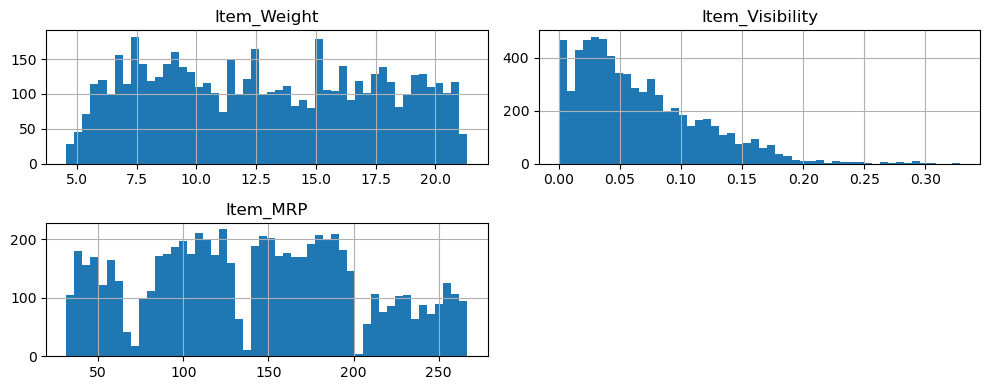

In [20]:
X_train[num_types].hist(bins=50,figsize=(10,4))
plt.tight_layout()

** Create Bins for the Continuous Numerical Features
- `Item_Weight:`    '0-11','11-18''>18'
- `Item_Visbility:` '0-0.10','>0.10-'
- `Item_MRP:`     '0-75','75-140','140-200','>250 

array([[<Axes: title={'center': 'Item_Outlet_Sales'}>]], dtype=object)

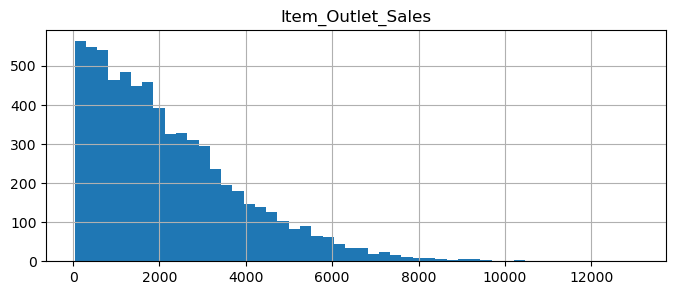

In [21]:
y_train_df.hist(bins=50,figsize=(8,3))

### 8.2 Impute Missing Values</a><a id='8.2'></a>

Handling Missing Data with SimpleImputer
https://www.analyticsvidhya.com/blog/2022/10/handling-missing-data-with-simpleimputer/

In [22]:
# Find missing numerical values for 'X_train'

X_train[num_types].isnull().sum()

Item_Weight        1174
Item_Visibility       0
Item_MRP              0
dtype: int64

In [23]:
X_train[num_types].describe()

,Item_Weight,Item_Visibility,Item_MRP
count,5644.000000,6818.000000,6818.000000
mean,12.886347,0.066097,141.905134
std,4.644777,0.051429,62.547789
min,4.555000,0.000000,31.290000
25%,8.880000,0.026939,94.175200
50%,12.600000,0.054129,144.262800
75%,16.850000,0.094791,186.855600
max,21.350000,0.328391,266.888400


In [24]:
# Find missing categorical values for 'X_train'

X_train[cat_types].isnull().sum()

Item_Fat_Content                0
Item_Type                       0
Outlet_Identifier               0
Outlet_Size                  1935
Outlet_Location_Type            0
Outlet_Type                     0
Outlet_Establishment_Year       0
dtype: int64

In [25]:
X_train[cat_types].describe()

,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Establishment_Year
count,6818,6818,6818,4883,6818,6818,6818
unique,5,16,10,3,3,4,9
top,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1,1985
freq,4035,1002,761,2233,2703,4446,1174


<Axes: >

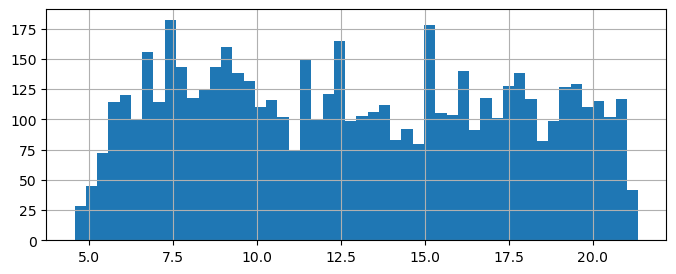

In [26]:
# Distribution of 'Item_Weight' values prior to impute

X_train['Item_Weight'].hist(bins=50,figsize=(8,3))

In [27]:
# Impute given numerical variable with mean value

def func_impute_missing_num_values_by_group(df, group_col, value_col):
    """Impute missing values in 'value_col' based 
    on the mean of each group in 'group_col'."""

    return df.groupby(group_col)[value_col].transform(lambda x: x.fillna(x.median()))

In [28]:
# Impute given categorical variable with mode value

def func_impute_missing_cat_values_by_group(df, group_col, value_col):
    """Impute missing values in 'value_col' based 
    on the mode of each group in 'group_col'."""
    
    return df.groupby(group_col)[value_col].transform(lambda x: x.fillna(x.mode()[0]))

In [29]:
# Impute missing values for 'Item_Weight'

X_train['Item_Weight'] = func_impute_missing_num_values_by_group(X_train,['Item_Type','Item_Fat_Content'], 'Item_Weight')
X_valid['Item_Weight'] = func_impute_missing_num_values_by_group(X_valid,'Item_Type', 'Item_Weight')
X_test['Item_Weight']  = func_impute_missing_num_values_by_group(X_test, 'Item_Type', 'Item_Weight')

# Impute missing values for 'Outlet_Size'

X_train['Outlet_Size'] = func_impute_missing_cat_values_by_group(X_train,'Outlet_Type','Outlet_Size')
X_valid['Outlet_Size'] = func_impute_missing_cat_values_by_group(X_valid,'Outlet_Type','Outlet_Size')
X_test['Outlet_Size']  = func_impute_missing_cat_values_by_group(X_test, 'Outlet_Type','Outlet_Size')

<Axes: >

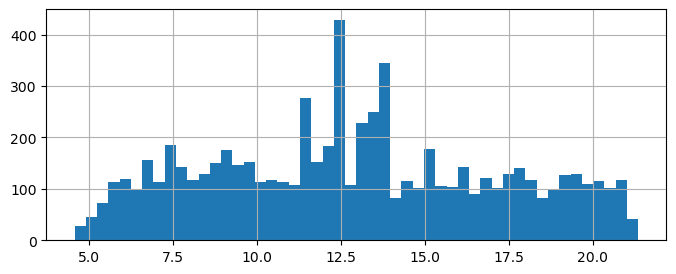

In [30]:
# # Distribution of 'Item_Weight' values after impute

X_train['Item_Weight'].hist(bins=50,figsize=(8,3))

In [31]:
X_train[cat_types].isnull().sum()

Item_Fat_Content             0
Item_Type                    0
Outlet_Identifier            0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Outlet_Establishment_Year    0
dtype: int64

In [32]:
X_train[num_types].isnull().sum()

Item_Weight        0
Item_Visibility    0
Item_MRP           0
dtype: int64

In [33]:
X_train.isnull().sum().sum(),X_valid.isnull().sum().sum(),X_test.isnull().sum().sum()

(0, 0, 0)

### 8.3 Find Measure of Dispersion

In [34]:
# Defining Interquartile Range

def func_find_up_low_values(data, col):
    
    q1  = data[col].quantile(0.25)
    q3  = data[col].quantile(0.75)
    iqr = q3 - q1
    up  = q3 + 1.5 * iqr
    low = q1 - 1.5 * iqr
    
    return low, up

In [35]:
# Lets find which feature has any outliers ?

def func_find_outlier(data, col, up, low):
    outlier = data[(data[col] > up) | (data[col] < low)].any(axis='columns')
    
    return outlier

In [36]:
# Lets add functionalty

def func_outlier_thresholds(dataframe, col_name, q1=0.25, q3=0.75):
    
    quartile1           = dataframe[col_name].quantile(q1)
    quartile3           = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    
    up_limit            = quartile3 + 1.5 * interquantile_range
    low_limit           = quartile1 - 1.5 * interquantile_range
    
    return low_limit, up_limit

In [37]:
# Identify Outliers from the numberical columns and plot displaying with other statistical values

def func_identify_outliers(df, col_list):
    
    index = 0
    j = 0
    for col in col_list:
        index += 1
        j += 1
        print(col, '--> Min: ',np.round(df[col].min(),2),' Max: ', np.round(df[col].max(),2), 'Mean: ', 
              np.round(df[col].mean(),2), 'Median: ', np.round(df[col].median(),2), 
              'Std Dev: ', np.round(df[col].std(),2))
        
        low, high = func_outlier_thresholds(df, col)
        print(col, '--> low limit(Q1): ',np.round(low,2),' high limit(Q3): ',np.round(high,2),
             ' IQR : ', np.round((high - low),2))
        print(col, '--> Skewness: ',np.round(df[col].skew(),2))
        is_outlier = func_find_outlier(df, col, low, high)
        if is_outlier.any() == True:
             print(col,"--> has outliers\n")
        else:
             print(col, '--> has no outliers\n')
        j = 0

In [38]:
func_identify_outliers(X_train,num_types)

Item_Weight --> Min:  4.56  Max:  21.35 Mean:  12.84 Median:  12.6 Std Dev:  4.26
Item_Weight --> low limit(Q1):  -0.9  high limit(Q3):  26.3  IQR :  27.2
Item_Weight --> Skewness:  0.11
Item_Weight --> has outliers

Item_Visibility --> Min:  0.0  Max:  0.33 Mean:  0.07 Median:  0.05 Std Dev:  0.05
Item_Visibility --> low limit(Q1):  -0.07  high limit(Q3):  0.2  IQR :  0.27
Item_Visibility --> Skewness:  1.16
Item_Visibility --> has outliers

Item_MRP --> Min:  31.29  Max:  266.89 Mean:  141.91 Median:  144.26 Std Dev:  62.55
Item_MRP --> low limit(Q1):  -44.85  high limit(Q3):  325.88  IQR :  370.72
Item_MRP --> Skewness:  0.11
Item_MRP --> has outliers



In [39]:
func_identify_outliers(y_train_df,y_train_df.columns)

Item_Outlet_Sales --> Min:  33.29  Max:  13086.96 Mean:  2202.37 Median:  1808.31 Std Dev:  1720.02
Item_Outlet_Sales --> low limit(Q1):  -2557.84  high limit(Q3):  6533.0  IQR :  9090.83
Item_Outlet_Sales --> Skewness:  1.18
Item_Outlet_Sales --> has outliers



### 8.4 Feature Engineering</a><a id='8.2'></a>

In [40]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Item_Weight                6818 non-null   float64 
 1   Item_Fat_Content           6818 non-null   category
 2   Item_Visibility            6818 non-null   float64 
 3   Item_Type                  6818 non-null   category
 4   Item_MRP                   6818 non-null   float64 
 5   Outlet_Identifier          6818 non-null   category
 6   Outlet_Establishment_Year  6818 non-null   category
 7   Outlet_Size                6818 non-null   category
 8   Outlet_Location_Type       6818 non-null   category
 9   Outlet_Type                6818 non-null   category
dtypes: category(7), float64(3)
memory usage: 208.6 KB


#### 8.4.1 Log Skewed Numerical Features and Target

In [41]:
# Apply log1p transformation using Numpy 

def func_log_transform(df_train,df_valid,df_test,cols,y_tr,y_val):
    
    log_cols=[]
    for col in cols:
        log_cols.append(col+'_log')
        df_train[col+'_log']=np.log1p(df_train[[col]])
        df_valid[col+'_log']=np.log1p(df_valid[[col]])
        df_test[col+'_log'] =np.log1p(df_test[[col]])
    #------------------------------------------------------
    y_log_tr  = np.log1p(y_tr)
    y_log_val = np.log1p(y_val)
    
    return df_train[log_cols],df_valid[log_cols],df_test[log_cols],log_cols,pd.Series(y_log_tr),pd.Series(y_log_val)

In [42]:
# Create separate logged datasets and column set

X_log_train,X_log_valid,X_log_test,logged_cols,y_log_train,y_log_valid = \
    func_log_transform(X_train[num_types],X_valid[num_types],X_test[num_types],num_types,y_train,y_valid)

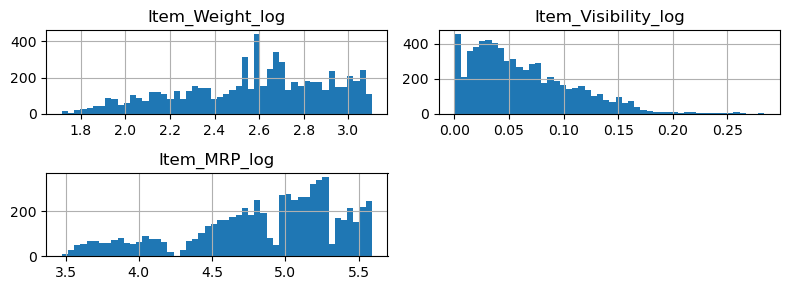

In [43]:
# Check out the distributio of the logged features

X_log_train.hist(bins=50,figsize=(8,3))
plt.tight_layout()

In [44]:
# Checkout Standard of Deviation of the logged columns

func_identify_outliers(X_log_train,logged_cols)

Item_Weight_log --> Min:  1.71  Max:  3.11 Mean:  2.58 Median:  2.61 Std Dev:  0.33
Item_Weight_log --> low limit(Q1):  1.57  high limit(Q3):  3.6  IQR :  2.03
Item_Weight_log --> Skewness:  -0.43
Item_Weight_log --> has outliers

Item_Visibility_log --> Min:  0.0  Max:  0.28 Mean:  0.06 Median:  0.05 Std Dev:  0.05
Item_Visibility_log --> low limit(Q1):  -0.07  high limit(Q3):  0.19  IQR :  0.26
Item_Visibility_log --> Skewness:  1.0
Item_Visibility_log --> has outliers

Item_MRP_log --> Min:  3.47  Max:  5.59 Mean:  4.84 Median:  4.98 Std Dev:  0.52
Item_MRP_log --> low limit(Q1):  3.54  high limit(Q3):  6.26  IQR :  2.72
Item_MRP_log --> Skewness:  -0.74
Item_MRP_log --> has outliers



In [45]:
# Checkout the Standard of Deviation of the logged target

y_log_train_df = pd.DataFrame(y_log_train,columns=['Item_Outlet_Sales'])
y_log_valid_df = pd.DataFrame(y_log_valid,columns=['Item_Outlet_Sales'])

func_identify_outliers(y_log_train_df,y_log_valid_df.columns)

Item_Outlet_Sales --> Min:  3.53  Max:  9.48 Mean:  7.31 Median:  7.5 Std Dev:  1.01
Item_Outlet_Sales --> low limit(Q1):  4.8  high limit(Q3):  10.0  IQR :  5.2
Item_Outlet_Sales --> Skewness:  -0.89
Item_Outlet_Sales --> has outliers



array([[<Axes: title={'center': 'Item_Outlet_Sales'}>]], dtype=object)

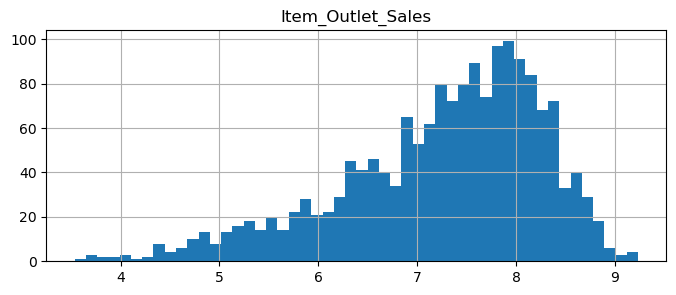

In [46]:
y_log_valid_df.hist(bins=50,figsize=(8,3))

In [47]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Item_Weight                6818 non-null   float64 
 1   Item_Fat_Content           6818 non-null   category
 2   Item_Visibility            6818 non-null   float64 
 3   Item_Type                  6818 non-null   category
 4   Item_MRP                   6818 non-null   float64 
 5   Outlet_Identifier          6818 non-null   category
 6   Outlet_Establishment_Year  6818 non-null   category
 7   Outlet_Size                6818 non-null   category
 8   Outlet_Location_Type       6818 non-null   category
 9   Outlet_Type                6818 non-null   category
dtypes: category(7), float64(3)
memory usage: 208.6 KB


#### 8.4.2 Qcut Skewed Numerical Features

In [48]:
def create_quartile_features(df_train,df_valid,df_test, column_name=num_types):
    """
    Creates new features based on quartiles of a continuous variable.

    Args:
        df (pd.DataFrame): The dataframe containing the data.
        column_name (str): The name of the continuous variable column.

    Returns:
        pd.DataFrame: The dataframe with new quartile features added.
    """
    quartile_col=[]
    for col in column_name:
        quartile_col.append(col+'_quartile')
        df_train[f'{col}_quartile'] = pd.qcut(df_train[col],10,labels=False)
        df_valid[f'{col}_quartile'] = pd.qcut(df_valid[col],10,labels=False)
        df_test[ f'{col}_quartile'] = pd.qcut(df_test[col], 10,labels=False)

    return df_train[quartile_col],df_valid[quartile_col],df_test[quartile_col],quartile_col

In [49]:
X_quartile_train,X_quartile_valid,X_quartile_test,quartiled_cols = \
    create_quartile_features(X_train[num_types],X_valid[num_types],X_test[num_types])

In [50]:
X_quartile_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Item_Weight_quartile      6818 non-null   int64
 1   Item_Visibility_quartile  6818 non-null   int64
 2   Item_MRP_quartile         6818 non-null   int64
dtypes: int64(3)
memory usage: 159.9 KB


In [51]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Item_Weight                6818 non-null   float64 
 1   Item_Fat_Content           6818 non-null   category
 2   Item_Visibility            6818 non-null   float64 
 3   Item_Type                  6818 non-null   category
 4   Item_MRP                   6818 non-null   float64 
 5   Outlet_Identifier          6818 non-null   category
 6   Outlet_Establishment_Year  6818 non-null   category
 7   Outlet_Size                6818 non-null   category
 8   Outlet_Location_Type       6818 non-null   category
 9   Outlet_Type                6818 non-null   category
dtypes: category(7), float64(3)
memory usage: 208.6 KB


#### 8.4.3  Binning

** Create Bins for the Continuous Numerical Features
- `Item_Weight:`    '0-11','11-18''>18'
- `Item_Visbility:` '0-0.10','>0.10'
- `Item_MRP:`     '0-75','75-140','140-200','>250 
<br>features:
<br>  age:
<br>    bins:
<br>      - [0, 18]
<br>      - [19, 35]
<br>      - [36, 65]
<br>      - [66, 100]

Dealing with configuration management
<br>https://github.com/ArjanCodes/2021-config/blob/main/after/conf/config.yaml

In [52]:
def read_yaml_config(file_path):
    """Reads a YAML config file and returns the configuration data."""

    import yaml
    with open(file_path, 'r') as file:
        config = yaml.safe_load(file)

    return config

In [53]:
def extract_bin_ranges(config, feature_name):
    """Extracts bin ranges for a given continuous feature from the config."""
    
    #print(config['features']['bin_category'])
    if feature_name in config['features']['bin_category']:
        #print(config['features']['bin_category'][feature_name])
        return config['features']['bin_category'][feature_name]

In [54]:
# Perform binning using quartile

def create_bin_features(df, config_file='bin_config.yaml',num_cols=num_types):
    """Bin dataframe columns"""
    
    binned_cols=[]
    config = read_yaml_config(config_file)
    for feature_name in num_cols:
        bin_ranges = extract_bin_ranges(config, feature_name)
        bin_colname = feature_name+'_bin'
        binned_cols.append(bin_colname)
        if feature_name == 'Item_Weight':
            bin_0=str(bin_ranges[0][0])+'-'+str(bin_ranges[0][1])
            bin_1=str(bin_ranges[0][1])+'-'+str(bin_ranges[0][2])
            bin_2='+'+str(bin_ranges[0][2])
            df.loc[(df[feature_name] >= bin_ranges[0][0])  & (df[feature_name] < bin_ranges[0][1]),bin_colname] = bin_0
            df.loc[(df[feature_name] >= bin_ranges[0][1])  & (df[feature_name] < bin_ranges[0][2]),bin_colname] = bin_1
            df.loc[(df[feature_name] >= bin_ranges[0][2])                                         ,bin_colname] = bin_2
        elif feature_name == 'Item_Visibility':
            bin_0=str(bin_ranges[0][0])+'-'+str(bin_ranges[0][1])
            bin_2='+'+str(bin_ranges[0][1])
            df.loc[(df[feature_name] >= bin_ranges[0][0])  & (df[feature_name] < bin_ranges[0][1]),bin_colname] = bin_0
            df.loc[(df[feature_name] >= bin_ranges[0][1])                                         ,bin_colname] = bin_1  
        elif feature_name == 'Item_MRP':
            bin_0=str(bin_ranges[0][0])+'-'+str(bin_ranges[0][1])
            bin_1=str(bin_ranges[0][1])+'-'+str(bin_ranges[0][2])
            bin_2=str(bin_ranges[0][2])+'-'+str(bin_ranges[0][3])
            bin_3='+'+str(bin_ranges[0][3])
            df.loc[(df[feature_name] >= bin_ranges[0][0])  & (df[feature_name] < bin_ranges[0][1]),bin_colname] = bin_0
            df.loc[(df[feature_name] >= bin_ranges[0][1])  & (df[feature_name] < bin_ranges[0][2]),bin_colname] = bin_1
            df.loc[(df[feature_name] >= bin_ranges[0][2])  & (df[feature_name] < bin_ranges[0][3]),bin_colname] = bin_2
            df.loc[(df[feature_name] >= bin_ranges[0][3])                                         ,bin_colname] = bin_3

    return df[binned_cols], binned_cols

In [55]:
X_binned_train,binned_cols = create_bin_features(X_train[num_types])
X_binned_valid,binned_cols = create_bin_features(X_valid[num_types])
X_binned_test ,binned_cols = create_bin_features(X_test[ num_types])
#---------------------------------------------------------------------
X_binned_train = func_typecast_object_to_cat(X_binned_train,binned_cols,'category')
X_binned_valid = func_typecast_object_to_cat(X_binned_valid,binned_cols,'category')
X_binned_test  = func_typecast_object_to_cat(X_binned_test ,binned_cols,'category')


In [56]:
X_binned_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Item_Weight_bin      6818 non-null   category
 1   Item_Visibility_bin  6818 non-null   category
 2   Item_MRP_bin         6818 non-null   category
dtypes: category(3)
memory usage: 20.6 KB


In [57]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Item_Weight                6818 non-null   float64 
 1   Item_Fat_Content           6818 non-null   category
 2   Item_Visibility            6818 non-null   float64 
 3   Item_Type                  6818 non-null   category
 4   Item_MRP                   6818 non-null   float64 
 5   Outlet_Identifier          6818 non-null   category
 6   Outlet_Establishment_Year  6818 non-null   category
 7   Outlet_Size                6818 non-null   category
 8   Outlet_Location_Type       6818 non-null   category
 9   Outlet_Type                6818 non-null   category
dtypes: category(7), float64(3)
memory usage: 208.6 KB


#### 8.4.3 Perform 'Min Max Scaling'</a><a id='8.4.3'></a> 

In [58]:
def func_scale_cols(df_train,df_valid,df_test):
    
    from sklearn.preprocessing import MinMaxScaler
    #--------------------------------------------
    # Create a MinMaxScaler instance
    scaler    = MinMaxScaler()
    #--------------------------------------------------------------------------------------------
    # Fit and transform the scaler on the numeric columns
    #--------------------------------------------------------------------------------------------
    df_train = scaler.fit_transform(df_train)
    df_valid = scaler.transform(df_valid)
    df_valid = scaler.transform(df_valid)
    #--------------------------------------------------------------------------------------------
    mnmx_cols = scaler.get_feature_names_out()
    df_train = pd.DataFrame(df_train,columns=mnmx_cols)
    df_valid = pd.DataFrame(df_valid,columns=mnmx_cols)
    df_test  = pd.DataFrame(df_test ,columns=mnmx_cols)

    return df_train,df_valid,df_test,mnmx_cols

In [59]:
# Create scaled datasets using MinMax Scaler for Numerical Features

X_mnmx_train,X_mnmx_valid,X_mnmx_test,mnmx_scaled_cols = \
    func_scale_cols(X_train[num_types],X_valid[num_types],X_test[num_types])

In [60]:
# Add Suffix to the Scaled Dataset columns

X_mnmx_train = X_mnmx_train.add_suffix('_mnmx')
X_mnmx_valid = X_mnmx_valid.add_suffix('_mnmx')
X_mnmx_test  = X_mnmx_test.add_suffix( '_mnmx')

In [61]:
func_identify_outliers(X_mnmx_train,X_mnmx_train.columns)

Item_Weight_mnmx --> Min:  0.0  Max:  1.0 Mean:  0.49 Median:  0.48 Std Dev:  0.25
Item_Weight_mnmx --> low limit(Q1):  -0.32  high limit(Q3):  1.29  IQR :  1.62
Item_Weight_mnmx --> Skewness:  0.11
Item_Weight_mnmx --> has outliers

Item_Visibility_mnmx --> Min:  0.0  Max:  1.0 Mean:  0.2 Median:  0.16 Std Dev:  0.16
Item_Visibility_mnmx --> low limit(Q1):  -0.23  high limit(Q3):  0.6  IQR :  0.83
Item_Visibility_mnmx --> Skewness:  1.16
Item_Visibility_mnmx --> has outliers

Item_MRP_mnmx --> Min:  0.0  Max:  1.0 Mean:  0.47 Median:  0.48 Std Dev:  0.27
Item_MRP_mnmx --> low limit(Q1):  -0.32  high limit(Q3):  1.25  IQR :  1.57
Item_MRP_mnmx --> Skewness:  0.11
Item_MRP_mnmx --> has outliers



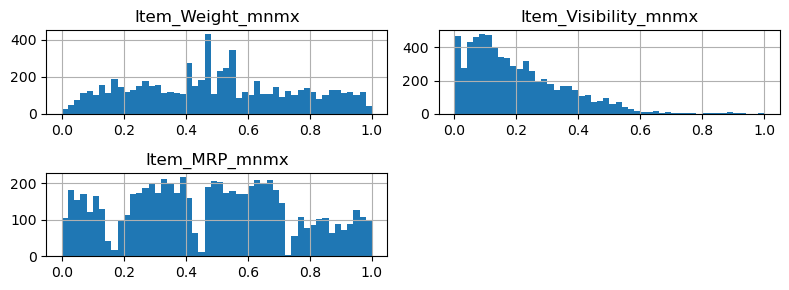

In [62]:
X_mnmx_train.hist(bins=50,figsize=(8,3));
plt.tight_layout()

In [63]:
X_mnmx_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Item_Weight_mnmx      6818 non-null   float64
 1   Item_Visibility_mnmx  6818 non-null   float64
 2   Item_MRP_mnmx         6818 non-null   float64
dtypes: float64(3)
memory usage: 159.9 KB


In [64]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Item_Weight                6818 non-null   float64 
 1   Item_Fat_Content           6818 non-null   category
 2   Item_Visibility            6818 non-null   float64 
 3   Item_Type                  6818 non-null   category
 4   Item_MRP                   6818 non-null   float64 
 5   Outlet_Identifier          6818 non-null   category
 6   Outlet_Establishment_Year  6818 non-null   category
 7   Outlet_Size                6818 non-null   category
 8   Outlet_Location_Type       6818 non-null   category
 9   Outlet_Type                6818 non-null   category
dtypes: category(7), float64(3)
memory usage: 208.6 KB


### 8.4 Clean Categories (Before Encoding)</a><a id='8.4'></a>

**Item_Fat_Content** (`Ordinal Encoding`)
- Make categorical values similar like 'Low Fat', 'low fat' and 'LF' --> 'LF'; 'Regular' and 'reg'--> 'REG'
- Encode 'LF'--> 0; 'REG'--> 1

In [65]:
X_train['Item_Fat_Content'].value_counts()

Low Fat    4035
Regular    2336
LF          267
reg          93
low fat      87
Name: Item_Fat_Content, dtype: int64

**Outlet Size**(`Ordinal Encoding`)
- Encode 'Small':0;'Medium':1;'High':2

In [66]:
X_train['Outlet_Size'].value_counts()

Small     3841
Medium    2233
High       744
Name: Outlet_Size, dtype: int64

**Outlet_Location_Type**(`Ordinal Encoding`)
- Encode 'Tier 1':0;'Tier 2':1;'Tier 3':2

In [67]:
X_train['Outlet_Location_Type'].value_counts()

Tier 3    2703
Tier 2    2239
Tier 1    1876
Name: Outlet_Location_Type, dtype: int64

**Function to clean categories for 'Item_Fat_Content'**

In [68]:
def func_clean_item_fat(df,col):

    # Dictionary to clean categories
    Item_Fat_Content_dict = {'Low Fat':'LF','LF':'LF','low fat':'LF','Regular':'REG','reg':'REG'}

    return df[col].map(Item_Fat_Content_dict)

In [69]:
X_train['Item_Fat_Content'] = func_clean_item_fat(X_train,'Item_Fat_Content')
X_valid['Item_Fat_Content'] = func_clean_item_fat(X_valid,'Item_Fat_Content')
X_test['Item_Fat_Content']  = func_clean_item_fat(X_test ,'Item_Fat_Content')
#-----------------------------------------------------------------------------------
X_train['Item_Fat_Content'] = X_train['Item_Fat_Content'].astype('category')
X_valid['Item_Fat_Content'] = X_valid['Item_Fat_Content'].astype('category')
X_test[ 'Item_Fat_Content'] = X_test[ 'Item_Fat_Content'].astype('category')
#-----------------------------------------------------------------------------------
X_train['Item_Fat_Content'].value_counts()

LF     4389
REG    2429
Name: Item_Fat_Content, dtype: int64

In [70]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Item_Weight                6818 non-null   float64 
 1   Item_Fat_Content           6818 non-null   category
 2   Item_Visibility            6818 non-null   float64 
 3   Item_Type                  6818 non-null   category
 4   Item_MRP                   6818 non-null   float64 
 5   Outlet_Identifier          6818 non-null   category
 6   Outlet_Establishment_Year  6818 non-null   category
 7   Outlet_Size                6818 non-null   category
 8   Outlet_Location_Type       6818 non-null   category
 9   Outlet_Type                6818 non-null   category
dtypes: category(7), float64(3)
memory usage: 208.5 KB


### 8.6 Perform 'One Hot Encoding'</a><a id='8.6'></a> 

In [71]:
# Funtion to encode columns to prepare datasets ready for next modeling steps

def func_ohe_cols(df_train,df_valid,df_test,cat_types=cat_types):
    
    from sklearn.preprocessing import OneHotEncoder
    #--------------------------------------------
    # Create a MinMaxScaler instance
    ohe = OneHotEncoder(sparse_output=False)
    #--------------------------------------------------------------------------------------------
    # Fit and transform the scaler on the numeric columns
    df_train_ohe = ohe.fit_transform(df_train)
    df_valid_ohe = ohe.transform(df_valid)
    df_test_ohe  = ohe.transform(df_test)
    #--------------------------------------------------------------------------------------------
    ohe_columns = ohe.get_feature_names_out()
    
    return df_train_ohe,df_valid_ohe,df_test_ohe,ohe_columns

In [72]:
# Perform 'OneHot Encoding' to the 'Categorical' columns
#-------------------------------------------------------------------------------------------------------------------
X_ohe_cat_train,X_ohe_cat_valid,X_ohe_cat_test,ohe_cat_cols = \
    func_ohe_cols(X_train[cat_types],X_valid[cat_types],X_test[cat_types])
#-------------------------------------------------------------------------------------------------------------------
X_ohe_cat_train = pd.DataFrame(X_ohe_cat_train,columns=ohe_cat_cols)
X_ohe_cat_valid = pd.DataFrame(X_ohe_cat_valid,columns=ohe_cat_cols)
X_ohe_cat_test  = pd.DataFrame(X_ohe_cat_test, columns=ohe_cat_cols)
X_ohe_cat_train = X_ohe_cat_train.add_suffix('_ohe')
X_ohe_cat_valid = X_ohe_cat_valid.add_suffix('_ohe')
X_ohe_cat_test  = X_ohe_cat_test.add_suffix( '_ohe')
#-------------------------------------------------------------------------------------------------------------------
# Perform 'OneHot Encoding' to the 'Quartile' columns treating as Numerical Categorical
#-------------------------------------------------------------------------------------------------------------------
X_ohe_quartile_train,X_ohe_quartile_valid,X_ohe_quartile_test,ohe_quartile_cols = \
    func_ohe_cols(X_quartile_train[quartiled_cols],X_quartile_valid[quartiled_cols],X_quartile_test[quartiled_cols])
#-------------------------------------------------------------------------------------------------------------------
X_ohe_quartile_train = pd.DataFrame(X_ohe_quartile_train,columns=ohe_quartile_cols)
X_ohe_quartile_valid = pd.DataFrame(X_ohe_quartile_valid,columns=ohe_quartile_cols)
X_ohe_quartile_test  = pd.DataFrame(X_ohe_quartile_test, columns=ohe_quartile_cols)
#-------------------------------------------------------------------------------------------------------------------
X_ohe_quartile_train = X_ohe_quartile_train.add_suffix('_ohe')
X_ohe_quartile_valid = X_ohe_quartile_valid.add_suffix('_ohe')
X_ohe_quartile_test  = X_ohe_quartile_test.add_suffix( '_ohe')
#-------------------------------------------------------------------------------------------------------------------
# Perform 'OneHot Encoding' to the 'Binned' columns
#-------------------------------------------------------------------------------------------------------------------
X_ohe_bin_train,X_ohe_bin_valid,X_ohe_bin_test,ohe_binned_cols = \
    func_ohe_cols(X_binned_train[binned_cols],X_binned_valid[binned_cols],X_binned_test[binned_cols])
#-------------------------------------------------------------------------------------------------------------------
X_ohe_bin_train = pd.DataFrame(X_ohe_bin_train,columns=ohe_binned_cols)
X_ohe_bin_valid = pd.DataFrame(X_ohe_bin_valid,columns=ohe_binned_cols)
X_ohe_bin_test  = pd.DataFrame(X_ohe_bin_test, columns=ohe_binned_cols)
X_ohe_bin_train = X_ohe_bin_train.add_suffix('_ohe')
X_ohe_bin_valid = X_ohe_bin_valid.add_suffix('_ohe')
X_ohe_bin_test  = X_ohe_bin_test.add_suffix( '_ohe')


In [73]:
X_ohe_cat_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 47 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Item_Fat_Content_LF_ohe              6818 non-null   float64
 1   Item_Fat_Content_REG_ohe             6818 non-null   float64
 2   Item_Type_Baking Goods_ohe           6818 non-null   float64
 3   Item_Type_Breads_ohe                 6818 non-null   float64
 4   Item_Type_Breakfast_ohe              6818 non-null   float64
 5   Item_Type_Canned_ohe                 6818 non-null   float64
 6   Item_Type_Dairy_ohe                  6818 non-null   float64
 7   Item_Type_Frozen Foods_ohe           6818 non-null   float64
 8   Item_Type_Fruits and Vegetables_ohe  6818 non-null   float64
 9   Item_Type_Hard Drinks_ohe            6818 non-null   float64
 10  Item_Type_Health and Hygiene_ohe     6818 non-null   float64
 11  Item_Type_Household_ohe       

In [74]:
X_ohe_quartile_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Item_Weight_quartile_0_ohe      6818 non-null   float64
 1   Item_Weight_quartile_1_ohe      6818 non-null   float64
 2   Item_Weight_quartile_2_ohe      6818 non-null   float64
 3   Item_Weight_quartile_3_ohe      6818 non-null   float64
 4   Item_Weight_quartile_4_ohe      6818 non-null   float64
 5   Item_Weight_quartile_5_ohe      6818 non-null   float64
 6   Item_Weight_quartile_6_ohe      6818 non-null   float64
 7   Item_Weight_quartile_7_ohe      6818 non-null   float64
 8   Item_Weight_quartile_8_ohe      6818 non-null   float64
 9   Item_Weight_quartile_9_ohe      6818 non-null   float64
 10  Item_Visibility_quartile_0_ohe  6818 non-null   float64
 11  Item_Visibility_quartile_1_ohe  6818 non-null   float64
 12  Item_Visibility_quartile_2_ohe  68

In [75]:
X_ohe_bin_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Item_Weight_bin_+18_ohe        6818 non-null   float64
 1   Item_Weight_bin_0-11_ohe       6818 non-null   float64
 2   Item_Weight_bin_11-18_ohe      6818 non-null   float64
 3   Item_Visibility_bin_0-0.1_ohe  6818 non-null   float64
 4   Item_Visibility_bin_11-18_ohe  6818 non-null   float64
 5   Item_MRP_bin_+200_ohe          6818 non-null   float64
 6   Item_MRP_bin_0-75_ohe          6818 non-null   float64
 7   Item_MRP_bin_140-200_ohe       6818 non-null   float64
 8   Item_MRP_bin_75-140_ohe        6818 non-null   float64
dtypes: float64(9)
memory usage: 479.5 KB


### 8.7 Perform 'Ordinal Encoding'</a><a id='8.7'></a> 

In [76]:
# Function to encode using Ordinal Encoding

def func_Ordinal_Encoding(df):
    Outlet_Size_mapping            = {'Small':0,'Medium':1,'High':2}
    Outlet_Location_Type_mapping   = {'Tier 1':0,'Tier 2':1,'Tier 3':2}
    #-------------------------------------------------------------------------------------------
    df['Outlet_Size_ord']          = df['Outlet_Size'].map(Outlet_Size_mapping)
    df['Outlet_Location_Type_ord'] = df['Outlet_Location_Type'].map(Outlet_Location_Type_mapping)
    #-------------------------------------------------------------------------------------------
    df['Outlet_Size_ord']          = df['Outlet_Size_ord'].astype('float64')
    df['Outlet_Location_Type_ord'] = df['Outlet_Location_Type_ord'].astype('float64')
    #-------------------------------------------------------------------------------------------
    
    return df[['Outlet_Size_ord','Outlet_Location_Type_ord']]

In [77]:
X_ordinal_train = func_Ordinal_Encoding(X_train[ordinal_encode])
X_ordinal_valid = func_Ordinal_Encoding(X_valid[ordinal_encode])
X_ordinal_test  = func_Ordinal_Encoding(X_test[ordinal_encode])

In [78]:
X_ordinal_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Outlet_Size_ord           6818 non-null   float64
 1   Outlet_Location_Type_ord  6818 non-null   float64
dtypes: float64(2)
memory usage: 106.7 KB


### 8.8 List individual OHE, Scaled Datasets and Combine as needed</a><a id='8.8'></a> 
#### 1. (Categorical: Ordinal Subset) - Always Choose this subset
X_ordinal_train,X_ordinal_valid,X_ordinal_test (ordinal_encode)
#### 2. (Categorical: OHE Subset) - Always Choose this subset
X_ohe_cat_train,X_ohe_cat_valid,X_ohe_cat_test (ohe_cat_cols)
#### 3. (Numerical: Continuous Subset) - Choose One of this (DO NOT Pick from 4)
3.1.X_log_train,X_log_valid,X_log_test (logged_cols)
<br>3.2.X_quartile_train,X_quartile_valid,X_quartile_test (quartiled_cols)
<br>3.3.X_mnmx_train,X_mnmx_valid,X_mnmx_test (mnmx_scaled_cols)
#### 4. (Numerical: Categorical Subset) - Choose One of this (DO NOT Pick from 3)
4.1.X_ohe_bin_train,X_ohe_bin_valid,X_ohe_bin_test, (binned_cols)
<br>4.2.X_ohe_quartile_train,X_ohe_quartile_valid,X_ohe_quartile_test (ohe_quartile_cols)

### Set A (Ordinal + OHE + One Set from Scaled Numerical)
**A1:** 1 + 2 + 3.1
<br>**A2:** 1 + 2 + 3.2
<br>**A3:** 1 + 2 + 3.3
### Set B (Ordinal + OHE + One Set from OHE Categorical)
**B1:** 1 + 2 + 4.1
<br>**B2:** 1 + 2 + 4.2

In [79]:
# A1 (Using Logged Numerical Columns)

X_ord_ohe_log_train = pd.concat([X_ordinal_train,X_ohe_cat_train,X_log_train],axis=1)
X_ord_ohe_log_valid = pd.concat([X_ordinal_valid,X_ohe_cat_valid,X_log_valid],axis=1)
X_ord_ohe_log_test  = pd.concat([X_ordinal_test ,X_ohe_cat_test ,X_log_test] ,axis=1)

A1 = {'X_train':X_ord_ohe_log_train,'X_valid':X_ord_ohe_log_valid,'X_test':X_ord_ohe_log_test}

In [80]:
# A1['X_train'].info()

In [81]:
# A2 (Using Quartile Numerical Columns)

X_ord_ohe_quartile_train = pd.concat([X_ordinal_train,X_ohe_cat_train,X_quartile_train],axis=1)
X_ord_ohe_quartile_valid = pd.concat([X_ordinal_valid,X_ohe_cat_valid,X_quartile_valid],axis=1)
X_ord_ohe_quartile_test  = pd.concat([X_ordinal_test ,X_ohe_cat_test ,X_quartile_test] ,axis=1)

A2 = {'X_train':X_ord_ohe_quartile_train,'X_valid':X_ord_ohe_quartile_valid,'X_test':X_ord_ohe_quartile_test}

In [82]:
# A2['X_train'].info()

In [83]:
# A3 (Using Scaled MinMax Numerical Columns)

X_ord_ohe_mnmx_train = pd.concat([X_ordinal_train,X_ohe_cat_train,X_mnmx_train],axis=1)
X_ord_ohe_mnmx_valid = pd.concat([X_ordinal_valid,X_ohe_cat_valid,X_mnmx_valid],axis=1)
X_ord_ohe_mnmx_test  = pd.concat([X_ordinal_test ,X_ohe_cat_test ,X_mnmx_test] ,axis=1)

A3 = {'X_train':X_ord_ohe_mnmx_train,'X_valid':X_ord_ohe_mnmx_valid,'X_test':X_ord_ohe_mnmx_test}

In [84]:
# A3['X_train'].info()

In [85]:
# B1 (Using Binned OHE Columns)

X_ord_ohe_bin_train = pd.concat([X_ordinal_train,X_ohe_cat_train,X_ohe_bin_train],axis=1)
X_ord_ohe_bin_valid = pd.concat([X_ordinal_valid,X_ohe_cat_valid,X_ohe_bin_valid],axis=1)
X_ord_ohe_bin_test  = pd.concat([X_ordinal_test ,X_ohe_cat_test ,X_ohe_bin_test] ,axis=1)

B1 = {'X_train':X_ord_ohe_bin_train,'X_valid':X_ord_ohe_bin_valid,'X_test':X_ord_ohe_bin_test}

In [86]:
# B1['X_train'].info()

In [87]:
# B2 (Using Binned OHE Columns)

X_ord_ohe_quartile_train = pd.concat([X_ordinal_train,X_ohe_cat_train,X_ohe_quartile_train],axis=1)
X_ord_ohe_quartile_valid = pd.concat([X_ordinal_valid,X_ohe_cat_valid,X_ohe_quartile_valid],axis=1)
X_ord_ohe_quartile_test  = pd.concat([X_ordinal_test ,X_ohe_cat_test ,X_ohe_quartile_test] ,axis=1)

B2 = {'X_train':X_ord_ohe_quartile_train,'X_valid':X_ord_ohe_quartile_valid,'X_test':X_ord_ohe_quartile_test}

In [88]:
# B2['X_train'].info()

In [89]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Item_Weight                6818 non-null   float64 
 1   Item_Fat_Content           6818 non-null   category
 2   Item_Visibility            6818 non-null   float64 
 3   Item_Type                  6818 non-null   category
 4   Item_MRP                   6818 non-null   float64 
 5   Outlet_Identifier          6818 non-null   category
 6   Outlet_Establishment_Year  6818 non-null   category
 7   Outlet_Size                6818 non-null   category
 8   Outlet_Location_Type       6818 non-null   category
 9   Outlet_Type                6818 non-null   category
dtypes: category(7), float64(3)
memory usage: 208.5 KB


In [90]:
(A1['X_train'].shape,A1['X_valid'].shape),(A2['X_train'].shape,A2['X_valid'].shape),\
(A3['X_train'].shape,A3['X_valid'].shape),(B1['X_train'].shape,B1['X_valid'].shape),\
(B2['X_train'].shape,B2['X_valid'].shape)

(((6818, 52), (1705, 52)),
 ((6818, 52), (1705, 52)),
 ((6818, 52), (1705, 52)),
 ((6818, 58), (1705, 58)),
 ((6818, 79), (1705, 79)))

### 8.8 Save Dataframe</a><a id='8.8'></a> 

In [91]:
# Save the current state of DataFrame to Excel and pickle file
#----------------------------------------------------------

# B1['X_train'].to_pickle('B1_X_train.pkl')
# B1['X_valid'].to_pickle('B1_X_valid.pkl')
# B2['X_train'].to_pickle('B2_X_train.pkl')
# B2['X_valid'].to_pickle('B2_X_valid.pkl')
# y_train.to_pickle('y_train.pkl')
# y_valid.to_pickle('y_valid.pkl')

# Read saved Pickle files for B1 and B2 datasets
# import pickle

# with open('B1_X_train.pkl', 'rb') as f:
#     B1['X_train'] = pickle.load(f)
# with open('B1_X_valid.pkl', 'rb') as f:
#     B1['X_valid'] = pickle.load(f)
# with open('B2_X_train.pkl', 'rb') as f:
#     B2['X_train'] = pickle.load(f)
# with open('B2_X_valid.pkl', 'rb') as f:
#     B2['X_valid'] = pickle.load(f)

In [92]:
# Choose current Scaled Dataset from A1/A2/A3/B1/B2

X_scaled_train = A1['X_train']
X_scaled_valid = A1['X_valid']
# X_scaled_train = A2['X_train']
# X_scaled_valid = A2['X_valid']
# X_scaled_train = A3['X_train']
# X_scaled_valid = A3['X_valid']
# X_scaled_train = B1['X_train']
# X_scaled_valid = B1['X_valid']
# X_scaled_train = B2['X_train']
# X_scaled_valid = B2['X_valid']

In [93]:
X_scaled_train.shape,X_scaled_valid.shape

((6818, 52), (1705, 52))

In [94]:
# X_scaled_valid.info()

### 8.9 Define 'Baseline Model' Performance<a id='8.9'></a> 

**Compute Average Sales (Train and Valid Datasets)**

In [95]:
#calculate the average score of the train dataset

mean_sales_train = y_train.mean()
print("Average Sales(Train):",mean_sales_train)
mean_sales_log_train = y_log_train.mean()
print("Average Sales(Train):",mean_sales_train)
mean_sales_log_valid = y_log_train.mean()
print("Average Sales(Train):",mean_sales_train)

mean_sales_valid = y_valid.mean()
print("Average Sales(Valid):",mean_sales_valid)

Average Sales(Train): 2202.365231211499
Average Sales(Train): 2202.365231211499
Average Sales(Train): 2202.365231211499
Average Sales(Valid): 2097.0083659824045


**Compute MAE Sales (Train and Valid Datasets)**

In [96]:
#Calculate the Mean Absolute Error on the test dataset

print("MAE(Train):",abs(np.subtract(y_train, mean_sales_train)).mean())
print("MAE(Valid):",abs(np.subtract(y_valid, mean_sales_valid)).mean())
print("MAE(Train):",abs(np.subtract(y_log_train, mean_sales_valid)).mean())
#
print("\nMAE(Log Train):",abs(np.subtract(y_log_train, mean_sales_log_train)).mean())
print("MAE(Log Valid):",abs(np.subtract(y_log_valid, mean_sales_log_valid)).mean())

MAE(Train): 1357.4626666789145
MAE(Valid): 1301.9849003947331
MAE(Train): 2089.698896820245

MAE(Log Train): 0.7989731006841285
MAE(Log Valid): 0.8055811654697385


 9. Build  'Base Models' <a id='9'></a> 


Hyperparameter Tuning in Linear Regression
<br>https://www.geeksforgeeks.org/hyperparameter-tuning-in-linear-regression/
<br>Ridge and Lasso Regression in Python
<br>https://www.analyticsvidhya.com/blog/2016/01/ridge-lasso-regression-python-complete-tutorial/
<br>Decision Trees: Split Methods & Hyperparameter Tuning
<br>https://www.analyticsvidhya.com/blog/2024/03/decision-trees-split-methods-hyperparameter-tuning/
"""

 random_forest_grid = {
     'max_depth'   : [3,4,5,6],'min_samples_split': [2,3,4,5],'min_samples_leaf': [3,4,5,6],
     'max_features': ['auto','sqrt','log2'],'criterion': ['squared_error','friedman_mse','absolute_error','poisson']
 }

 parameters={"splitter":["best","random"],
             "max_depth" : [1,3,5,7,9,11,12],
            "min_samples_leaf":[1,2,3,4,5,6,7,8,9,10],
            "min_weight_fraction_leaf":[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
            "max_features":["auto","log2","sqrt",None],
            "max_leaf_nodes":[None,10,20,30,40,50,60,70,80,90] }
"""

In [97]:
from sklearn.linear_model    import LinearRegression,Lasso,Ridge,ElasticNet,BayesianRidge
from sklearn.model_selection import GridSearchCV, cross_validate, RepeatedStratifiedKFold,KFold
from sklearn.ensemble        import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,StackingRegressor
from sklearn.tree            import DecisionTreeRegressor
from xgboost                 import XGBRegressor

from sklearn.metrics import r2_score,explained_variance_score,mean_squared_error as mse,mean_absolute_error as mae
from math import sqrt
from statsmodels.graphics.gofplots import qqplot

In [98]:
# List GridSearchCV Parameters for the respective Regressor Model

LinearReg_grid = {'copy_X': [True,False],'fit_intercept': [True,False],'positive': [True,False]}
Lasso_grid     = {'alpha': [0.1,1,5,10,15,25,30,35,40,45,50,55]}
Ridge_grid     = {'alpha': [0.1,1,5,10,15,25,30,35,40,45,50,55]}
Bayesian_grid  = {'alpha_1': [0.1,1,5,10,15,25,30,35,40,45,50,55],
                'alpha_2': [0.1,1,5,10,15,25,30,35,40,45,50,55],
                'compute_score': [True,False],'copy_X': [True,False],
                'fit_intercept': [True,False]
}
elastic_grid   = {'max_iter': [1,3,5,7,8,10],'alpha': [0.1,1,5,10,15,25,30,35,40,45,50,55],
                  'l1_ratio': np.arange(0.0, 1.0, 0.1)}
decison_grid = {
    'max_depth'   : [27,30,32,35,37,40,42,45],'min_samples_split': [15,17,19,22,25],
    'min_samples_leaf': [15,17,19,22],'max_features': ['auto','sqrt','log2'],
    'criterion': ['squared_error','friedman_mse','absolute_error','poisson']
}
random_forest_grid = {
    'max_depth'   : [27,30,32,35,37,40,42,45],'min_samples_split': [15,17,19,22,25],
    'min_samples_leaf': [15,17,19,22],'max_features': ['sqrt', 'log2'],'criterion': ['squared_error']
}
gradient_boosting_grid = {'n_estimators': [50, 100, 200],'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]
}
xgboost_grid = {'n_estimators': [100, 200, 300],'max_depth': [3, 5, 7],'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],'colsample_bytree': [0.8, 0.9, 1.0]
}
adaboost_grid = {'n_estimators':[10,50,250,1000],'learning_rate':[0.01,0.1]
}

In [99]:
# List Regressor Models for GridSearchCV
# regressors = {
#     'Linear-Regression-BM'             ,LinearRegression(copy_X= True,fit_intercept=True,positive=True),
#     'Lasso-Regression-BM'              ,Lasso(alpha=25),
#     'Ridge-Regression-BM'              ,Ridge(alpha=65),
#     'Elastic-Net-Regression-BM'        ,ElasticNet(alpha=0.1,l1_ratio=0.9,max_iter=3),
#     'Decision-Tree-Regression-BM'      ,DecisionTreeRegressor(criterion='poisson',max_depth=15,max_features='sqrt',min_samples_leaf=15,min_samples_split=15),
#     'Random-Forest-Regression-BM'      ,RandomForestRegressor(criterion='squared_error',max_depth=35,max_features='sqrt',min_samples_leaf=10,min_samples_split=10),
#     'Gradient-Boosting-Regression-BM'  ,GradientBoostingRegressor(learning_rate=0.01,max_depth=7,min_samples_leaf=10,min_samples_split=10,n_estimators=1000),
#     'XGBoosting-Regression-BM'         ,XGBRegressor(colsample_bytree= 0.9,learning_rate=0.01,max_depth=5,n_estimators=1000,subsample=0.8),
#     'Ada-Boosting-Regression-BM'       ,AdaBoostRegressor(learning_rate=0.01,n_estimators=1000)
#                                                               ,
#     'Linear-Regression-GSCV'           ,LinearRegression(),
#     'Lasso-Regression-GSCV'            ,Lasso(),
#     'Ridge-Regression-GSCV'            ,Ridge(),
#     'Elastic-Net-Regression-GSCV'      ,ElasticNet(),
#     'Decision-Tree-Regression-GSCV'    ,DecisionTreeRegressor(),
#     'Random-Forest-Regression-GSCV'    ,RandomForestRegressor(),
#     'Gradient-Boosting-Regression-GSCV',GradientBoostingRegressor(),
#     'XGBoosting-Regression-GSCV'       ,XGBRegressor(),
#     'Ada-Boosting-Regression-GSCV'     ,AdaBoostRegressor()
# }
estimators = [
    ('Linear-Regression-BM'           ,LinearRegression(copy_X= True,fit_intercept=True,positive=True)),
    ('Lasso-Regression-BM'            ,Lasso(alpha=25)),
    ('Ridge-Regression-BM'            ,Ridge(alpha=65)),
    ('Elastic-Net-Regression-BM'      ,ElasticNet(alpha=0.1,l1_ratio=0.9,max_iter=3)),
    ('Decision-Tree-Regression-BM'    ,DecisionTreeRegressor(criterion='poisson',max_depth=15,max_features='sqrt',min_samples_leaf=15,min_samples_split=15)),
    ('Random-Forest-Regression-BM'    ,RandomForestRegressor(criterion='squared_error',max_depth=35,max_features='sqrt',min_samples_leaf=10,min_samples_split=10)),
    ('Gradient-Boosting-Regression-BM',GradientBoostingRegressor(learning_rate=0.01,max_depth=7,min_samples_leaf=10,min_samples_split=10,n_estimators=1000)),
    ('XGBoosting-Regression-BM'       ,XGBRegressor(colsample_bytree= 0.9,learning_rate=0.01,max_depth=5,n_estimators=1000,subsample=0.8)),
    ('Ada-Boosting-Regression-BM'     ,AdaBoostRegressor(learning_rate=0.01,n_estimators=1000))
]
reg_params = [LinearReg_grid,LinearReg_grid,LinearReg_grid,LinearReg_grid,LinearReg_grid,
              LinearReg_grid,LinearReg_grid,LinearReg_grid,LinearReg_grid,LinearReg_grid,
              Lasso_grid,Ridge_grid,elastic_grid,decison_grid,random_forest_grid,
              gradient_boosting_grid,xgboost_grid,adaboost_grid]

In [101]:
#Function to perform Grid Search and compute Best Estimator, Score, Params to return y Predict
"""
GridSearchCV is a technique for finding the optimal hyperpthresholds_prcarameter values from a given set of parameters 
in a grid. It's essentially a cross-validation technique. The model as well as the parameters must be entered. 
After extracting the best parameter values, predictions are made.

The “best” parameters that GridSearchCV identifies are technically the best that could be produced, 
but only by the parameters that you included in your parameter grid.
"""
def func_perform_grid_search(model,X_train,y_train,X_valid,y_valid,cv_params,CV):
    
    #-------------------------------------------------------------------------------------------------
    name_grid_search    = GridSearchCV(estimator=model,param_grid=cv_params,n_jobs=-1,cv=CV,scoring='r2',refit=True)
    #-------------------------------------------------------------------------------------------------
    # Fit the GridSearchCV object to the training data and save the best set of hyperparameters
    #-------------------------------------------------------------------------------------------------
    name_grid_search.fit(X_train, y_train)
    #-------------------------------------------------------------------------------------------------
    name_best_estimator = name_grid_search.best_estimator_
    name_best_score     = name_grid_search.best_score_
    name_best_params    = name_grid_search.best_params_
    print('Best Parameters',name_grid_search.best_params_)
    #-------------------------------------------------------------------------------------------------
    # Make predictions using the "best estimator" and get the probabilities for Positive Class
    #-------------------------------------------------------------------------------------------------
    y_best_pred_train   = name_best_estimator.predict(X_train)
    y_best_pred_valid   = name_best_estimator.predict(X_valid)
    #-------------------------------------------------------------------------------------------------
    # Predicting over the Train Set and calculating error
    #-------------------------------------------------------------------------------------------------
    y_predict_train    = name_best_estimator.predict(X_train)
    mae_train          = mae(y_train, y_best_pred_train)
    mse_train          = mse(y_train, y_best_pred_train)
    r2_score_train     = r2_score(y_train, y_best_pred_train)

    y_predict_valid    = name_best_estimator.predict(X_valid)
    mae_valid          = mae(y_valid, y_best_pred_valid)
    mse_valid          = mse(y_valid, y_best_pred_valid)
    r2_score_valid     = r2_score(y_valid, y_best_pred_valid)

    return y_predict_train,y_predict_valid,mae_train,mae_valid,mse_train,mse_valid,r2_score_train,r2_score_valid

In [102]:
#-------------------------------------------------------------------------------------------------
# Perform Base Model and Predict Train and Valid 'y' using 'kfold'
#-------------------------------------------------------------------------------------------------
def func_perform_kfold_base_model(model,n_splits,X_train,y_train,X_valid,y_valid):
    
    from sklearn.model_selection import KFold
    y_predict_train = np.empty((0,0) , int)
    skfold = KFold(n_splits,random_state = 9,shuffle=True)
  
    #For every permutation of KFold
    for i,j in skfold.split(X_train, y_train):
        x_kf_train, x_kf_test = X_train.iloc[i], X_train.iloc[j]
        y_kf_train, y_kf_test = y_train.iloc[i], y_train.iloc[j]
    
        #Train a model on training set
        model.fit( X = x_kf_train, y = y_kf_train)
    
        #Predict on Chosen Group
        tmp = model.predict(x_kf_test)
    
        #Storing train predictions
        y_predict_train = np.append(y_predict_train, tmp)
        
    #-------------------------------------------------------------------------------------------------
    # Make predictions using the "best estimator" and get the probabilities for Positive Class
    #-------------------------------------------------------------------------------------------------
    # Predicting over the Train Set and calculating error
    #y_predict_train = model.predict(X_train)
    mae_train       = mae(y_train, y_predict_train)
    mse_train       = mse(y_train, y_predict_train)
    r2_score_train  = r2_score(y_train, y_predict_train)
    
    y_predict_valid = model.predict(X_valid)
    mae_valid       = mae(y_valid, y_predict_valid)
    mse_valid       = mse(y_valid, y_predict_valid)
    r2_score_valid  = r2_score(y_valid, y_predict_valid)
    #-------------------------------------------------------------------------------------------------
    
    return y_predict_train,y_predict_valid,mae_train,mae_valid,mse_train,mse_valid,r2_score_train,r2_score_valid

In [106]:
#-------------------------------------------------------------------------------------------------
# Perform Base Model and Predict Train and Valid 'y'
#-------------------------------------------------------------------------------------------------
def func_stacking_regressor(estimators,name,final_estimator,X_train,y_train,X_valid,y_valid):

    # Define the stacking regressor
    print('Stacking ',name)
    stacking_regressor = StackingRegressor(estimators=estimators,final_estimator=final_estimator,cv=5,n_jobs=-1)
    #-------------------------------------------------------------------------------------------------
    # Fit the stacking regressor
    #-------------------------------------------------------------------------------------------------
    stacking_regressor.fit(X_train, y_train)
    #-------------------------------------------------------------------------------------------------
    # Make Model predictions, Loss and Scores using the "stacking regressor"
    #-------------------------------------------------------------------------------------------------
    # Predicting over the Train Set and calculating error
    y_predict_train = stacking_regressor.predict(X_train)
    mae_train       = mae(y_train, y_predict_train)
    mse_train       = mse(y_train, y_predict_train)
    r2_score_train  = r2_score(y_train, y_predict_train)
    
    y_predict_valid = stacking_regressor.predict(X_valid)
    mae_valid       = mae(y_valid, y_predict_valid)
    mse_valid       = mse(y_valid, y_predict_valid)
    r2_score_valid  = r2_score(y_valid, y_predict_valid)
    #-------------------------------------------------------------------------------------------------
    
    return y_predict_train,y_predict_valid,mae_train,mae_valid,mse_train,mse_valid,r2_score_train,r2_score_valid

In [107]:
#-------------------------------------------------------------------------------------------------
# Perform Base Model and Predict Train and Valid 'y'
#-------------------------------------------------------------------------------------------------
def func_perform_base_model(model,X_train,y_train,X_valid,y_valid):

    # Perform cross-validation on the training data
    cv_results = cross_validate(model, X_train, y_train, cv=5,scoring='neg_mean_squared_error',return_train_score=True)
    #-------------------------------------------------------------------------------------------------
    model.fit(X_train, y_train)
    #-------------------------------------------------------------------------------------------------
    # Make predictions using the "best estimator" and get the probabilities for Positive Class
    #-------------------------------------------------------------------------------------------------
    # Predicting over the Train Set and calculating error
    y_predict_train = model.predict(X_train)
    mae_train       = mae(y_train, y_predict_train)
    mse_train       = mse(y_train, y_predict_train)
    r2_score_train  = r2_score(y_train, y_predict_train)
    
    y_predict_valid = model.predict(X_valid)
    mae_valid       = mae(y_valid, y_predict_valid)
    mse_valid       = mse(y_valid, y_predict_valid)
    r2_score_valid  = r2_score(y_valid, y_predict_valid)
    #-------------------------------------------------------------------------------------------------
    
    return y_predict_train,y_predict_valid,mae_train,mae_valid,mse_train,mse_valid,r2_score_train,r2_score_valid

In [108]:
#-------------------------------------------------------------------------------------------------
# Implement using Stacking Regressor
#-------------------------------------------------------------------------------------------------
model_names=[];y_predict_trains=[];y_predict_valids=[];residual_trains=[];residual_valids=[];
mae_trains=[];mae_valids=[];mse_trains=[];mse_valids=[];r2_score_trains=[];r2_score_valids=[]

for index,(name,estimator) in enumerate(estimators):
    print(index+1)
    final_estimator = estimator
    y_predict_train,y_predict_valid,mae_train,mae_valid,mse_train,mse_valid,r2_score_train,r2_score_valid = \
        func_stacking_regressor(estimators,name,final_estimator,X_scaled_train,y_train,X_scaled_valid,y_valid)
    #-------------------------------------------------------------------------------------------------
    residual_train = y_train - y_predict_train;residual_valid = y_valid - y_predict_valid
    #-------------------------------------------------------------------------------------------------
    model_names.append(name);y_predict_trains.append(y_predict_train);y_predict_valids.append(y_predict_valid);
    residual_trains.append(residual_train);residual_valids.append(residual_valid);
    mae_trains.append(mae_train);mae_valids.append(mae_valid);mse_trains.append(mse_train);mse_valids.append(mse_valid);
    r2_score_trains.append(r2_score_train);r2_score_valids.append(r2_score_valid)


1
Stacking  Linear-Regression-BM
2
Stacking  Lasso-Regression-BM
3
Stacking  Ridge-Regression-BM
4
Stacking  Elastic-Net-Regression-BM
5
Stacking  Decision-Tree-Regression-BM
6
Stacking  Random-Forest-Regression-BM
7
Stacking  Gradient-Boosting-Regression-BM
8
Stacking  XGBoosting-Regression-BM
9
Stacking  Ada-Boosting-Regression-BM


In [110]:
len(model_names);len(y_predict_trains),len(y_predict_valids),len(mae_trains),len(mae_valids),\
len(mse_trains),len(mse_valids),len(r2_score_trains),len(r2_score_valids)

(9, 9, 9, 9, 9, 9, 9, 9)

In [111]:
model_parms = {
    'Model':model_names,
    'MAE-Train':mae_trains,'MAE-Valid':mae_valids,\
    'MSE-Train':mse_trains,'MSE-Valid':mse_valids,\
    'R2-Score-Train':r2_score_trains,'R2-Score-Valid':r2_score_valids
}
model_parms = pd.DataFrame(model_parms)
model_parms.set_index('Model',drop=True,inplace=True)

In [112]:
model_parms.head(16)

,MAE-Train,MAE-Valid,MSE-Train,MSE-Valid,R2-Score-Train,R2-Score-Valid
Model,,,,,,
Linear-Regression-BM,725.094637,725.580947,1.024702e+06,1.052708e+06,0.653589,0.612686
Lasso-Regression-BM,732.987171,725.470613,1.045518e+06,1.056419e+06,0.646552,0.611321
Ridge-Regression-BM,735.575359,726.331644,1.051332e+06,1.055292e+06,0.644586,0.611735
Elastic-Net-Regression-BM,827.498044,795.099981,1.234280e+06,1.146630e+06,0.582739,0.578130
Decision-Tree-Regression-BM,813.463427,770.089349,1.382892e+06,1.259322e+06,0.532499,0.536668
Random-Forest-Regression-BM,749.994560,719.331936,1.158891e+06,1.070727e+06,0.608225,0.606056
Gradient-Boosting-Regression-BM,764.014895,731.521022,1.221958e+06,1.129447e+06,0.586904,0.584452
XGBoosting-Regression-BM,755.192335,722.894243,1.179746e+06,1.079021e+06,0.601175,0.603005
Ada-Boosting-Regression-BM,766.018608,759.502820,1.133055e+06,1.117661e+06,0.616959,0.588788


In [ ]:
fig,ax = plt.subplots(figsize=(17,6), nrows=1,ncols=3)
plt.suptitle("Compare Evaluation Metrices of 'Train & Valid Data'", fontsize=16)

model_parms.plot(y=['MAE-Train','MAE-Valid'],kind='bar',ax=ax[0]);
ax[0].tick_params(labelbottom=True, labelright=True,bottom=True,right=True)
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),ncols=3,fancybox=True, shadow=True)

model_parms.plot(y=['MSE-Train','MSE-Valid'],kind='bar',ax=ax[1]);
ax[1].tick_params(labelbottom=True, labelright=True,bottom=True,right=True)
ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),ncols=3,fancybox=True, shadow=True)

model_parms.plot(y=['R2-Score-Train','R2-Score-Valid'],kind='bar',ax=ax[2]);
ax[2].tick_params(labelbottom=True, labelright=True,bottom=True,right=True)
ax[2].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),ncols=3,fancybox=True, shadow=True)

plt.tight_layout()
plt.show()

In [ ]:
fig,axs = plt.subplots(figsize=(10,17), nrows=5,ncols=2)
plt.suptitle("Valid Vs. Valid-Predicted", fontsize=13)

for pos,ax in enumerate(axs.flatten()):

    if pos < 9:
        ax.scatter(y_valid, y_predict_valids[pos], c='crimson')
        ax.set_yscale('log')
        ax.set_xscale('log')
        p1 = max(max(y_predict_valids[pos]), max(y_valid))
        p2 = min(min(y_predict_valids[pos]), min(y_valid))
        ax.plot([p1, p2], [p1, p2], 'b-')
        ax.set_xlabel('Valid')
        ax.set_ylabel('Predicted')
        ax.axis('equal')
        title = model_names[pos]
        ax.set_title(title)
    
    plt.tight_layout()

In [ ]:
fig,axs = plt.subplots(figsize=(12,17), nrows=5,ncols=2)
plt.suptitle("Valid Vs. Valid-Predicted", fontsize=13)

for pos,ax in enumerate(axs.flatten()):
    if pos < 9:
        #Plot Actual Vs. Residual
        ax.scatter(y_valid.index, residual_valids[pos])
        ax.set_xlabel('Index')
        ax.set_ylabel('Residual')
        title = model_names[pos]
        ax.set_title(title)
        ax.axhline(0, color="#d62728")
    
    plt.tight_layout()

In [ ]:
fig,axs = plt.subplots(figsize=(8,10), nrows=5,ncols=2)
plt.suptitle("Valid Vs. Valid-Predicted", fontsize=13)

for pos,ax in enumerate(axs.flatten()):
    if pos < 9:
        ax.hist(residual_valids[pos], density = True, bins = 450)
        ax.set_xlim(-2000, 2000)
        title = model_names[pos]
        ax.set_title(title)
        ax.set_ylabel("Frequency")
        ax.set_xlabel("Residual")
    
    plt.tight_layout()
